# Projektni zadatak iz Ekonometrije

Prezime i ime: Petar  Belko \
Matični broj: 0066299238  
Akademska godina 2025./2026. \
Kategorija izdataka: GASO \
Period analize: 

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Učitavanje podataka
data_path = 'demand.xlsx'
df = pd.read_excel(data_path)

# Čišćenje podataka - zadržavamo samo potrebne stupce
cols_to_keep = ['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']
df = df[cols_to_keep]

print("=== Stupci nakon čišćenja ===")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())

=== Stupci nakon čišćenja ===
['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']

Prvih 5 redova:
        gaso   pgaso     dpi    ptpe     pop  time
0  60.744761  18.576  1715.5  20.432  177130     1
1  62.825049  19.112  1759.7  20.767  180760     2
2  63.473382  18.924  1819.2  20.985  183742     3
3  66.165106  19.043  1908.2  21.232  186590     4
4  68.197955  18.997  1979.1  21.479  189300     5


### Kreiranje Indeksa relativnih cijena

In [2]:
# Kreiranje Indeksa relativnih cijena
df['prgaso'] = 100 * (df['pgaso'] / df['ptpe'])
print("\nPrvih 5 redova:")
print(df.head(5)[['prgaso']])


Prvih 5 redova:
      prgaso
0  90.916210
1  92.030626
2  90.178699
3  89.690090
4  88.444527


### Osnovni deskriptivni pokazatelji dodijeljene kategorije (GASO)

=== Deskriptivni pokazatelji za GASO ===

1. Aritmetička sredina: 122.0260
   → Prosječna potrošnja benzina iznosi 122.0260 jedinica.

2. Medijan: 120.6637
   → Polovica promatranja ima potrošnju manju od 120.6637 jedinica.

3. Asimetrija (α₃): -0.0791
   → Distribucija je negativno asimetrična (rep je s lijeve strane).

4. Spljoštenost (α₄): -0.8297
   → Distribucija je plosnatija od normalne.

5. Standardna devijacija: 35.1763
   → Potrošnja benzina u prosjeku odstupa 35.1763 jedinica od aritmetičke sredine.


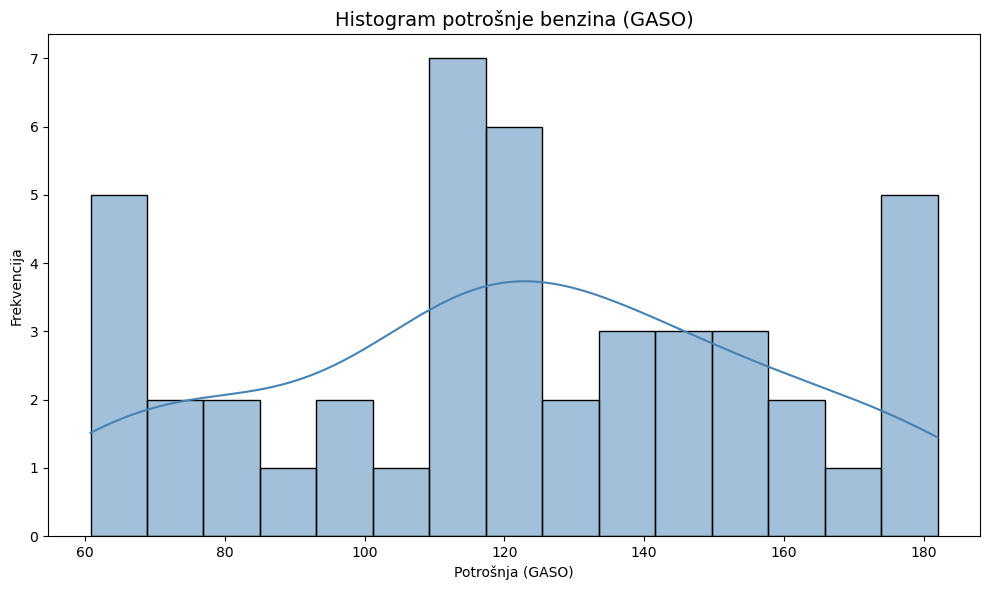

In [3]:
# Deskriptivni pokazatelji za GASO
print("=== Deskriptivni pokazatelji za GASO ===\n")

mean = df['gaso'].mean()
median = df['gaso'].median()
std = df['gaso'].std()
skew = df['gaso'].skew()
kurt = df['gaso'].kurtosis()

print(f"1. Aritmetička sredina: {mean:.4f}")
print(f"   → Prosječna potrošnja benzina iznosi {mean:.4f} jedinica.\n")

print(f"2. Medijan: {median:.4f}")
print(f"   → Polovica promatranja ima potrošnju manju od {median:.4f} jedinica.\n")

print(f"3. Asimetrija (α₃): {skew:.4f}")
if skew > 0:
    print(f"   → Distribucija je pozitivno asimetrična (rep je s desne strane).\n")
elif skew < 0:
    print(f"   → Distribucija je negativno asimetrična (rep je s lijeve strane).\n")
else:
    print(f"   → Distribucija je simetrična.\n")

print(f"4. Spljoštenost (α₄): {kurt:.4f}")
if kurt > 0:
    print(f"   → Distribucija je šiljatija od normalne.\n")
elif kurt < 0:
    print(f"   → Distribucija je plosnatija od normalne.\n")
else:
    print(f"   → Distribucija ima normalnu spljoštenost.\n")

print(f"5. Standardna devijacija: {std:.4f}")
print(f"   → Potrošnja benzina u prosjeku odstupa {std:.4f} jedinica od aritmetičke sredine.")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['gaso'], kde=True, color='steelblue', bins=15)
plt.title('Histogram potrošnje benzina (GASO)', fontsize=14)
plt.xlabel('Potrošnja (GASO)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()